✅ 使用中文字体: Heiti TC (路径: /System/Library/Fonts/STHeiti Medium.ttc)
豆瓣电影 Top 100 爬虫 + 数据可视化 完整流程

📌 爬取配置：共 100 部电影，每页 25 条，共 4 页

步骤 1: 检查并创建数据库表...
✅ 表 douban_movie 已创建或已存在

步骤 2: 开始爬取豆瓣电影 Top 100...
   正在爬取第 1 页 (start=0)...
   正在爬取第 2 页 (start=25)...
   正在爬取第 3 页 (start=50)...
   正在爬取第 4 页 (start=75)...

✅ 共爬取 100 部电影

步骤 3: 正在存入数据库...
✅ 成功存入 100 部电影到数据库

步骤 4: 从数据库加载数据用于可视化...
✅ 成功加载 900 条记录

数据预览（前 10 部电影）：
 movie_rank  title                director  year country genre rating  rating_people quote
          1 肖申克的救赎 弗兰克·德拉邦特 Frank Darabont  1994      美国    未知    9.7              0  None
          1 肖申克的救赎 弗兰克·德拉邦特 Frank Darabont  1994      美国    未知    9.7              0  None
          1 肖申克的救赎 弗兰克·德拉邦特 Frank Darabont  1994      美国    未知    9.7              0  None
          1 肖申克的救赎 弗兰克·德拉邦特 Frank Darabont  1994      美国    未知    9.7              0  None
          1 肖申克的救赎 弗兰克·德拉邦特 Frank Darabont  1994      美国    未知    9.7              0  None
          1 肖申克的救赎 弗兰克·德拉邦特 Frank Darabo

/var/folders/wn/m8zzwq0937zdk24d66jmxl8h0000gn/T/ipykernel_90571/4261313678.py:325: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['rating_people'] = df['rating_people'].fillna(0)


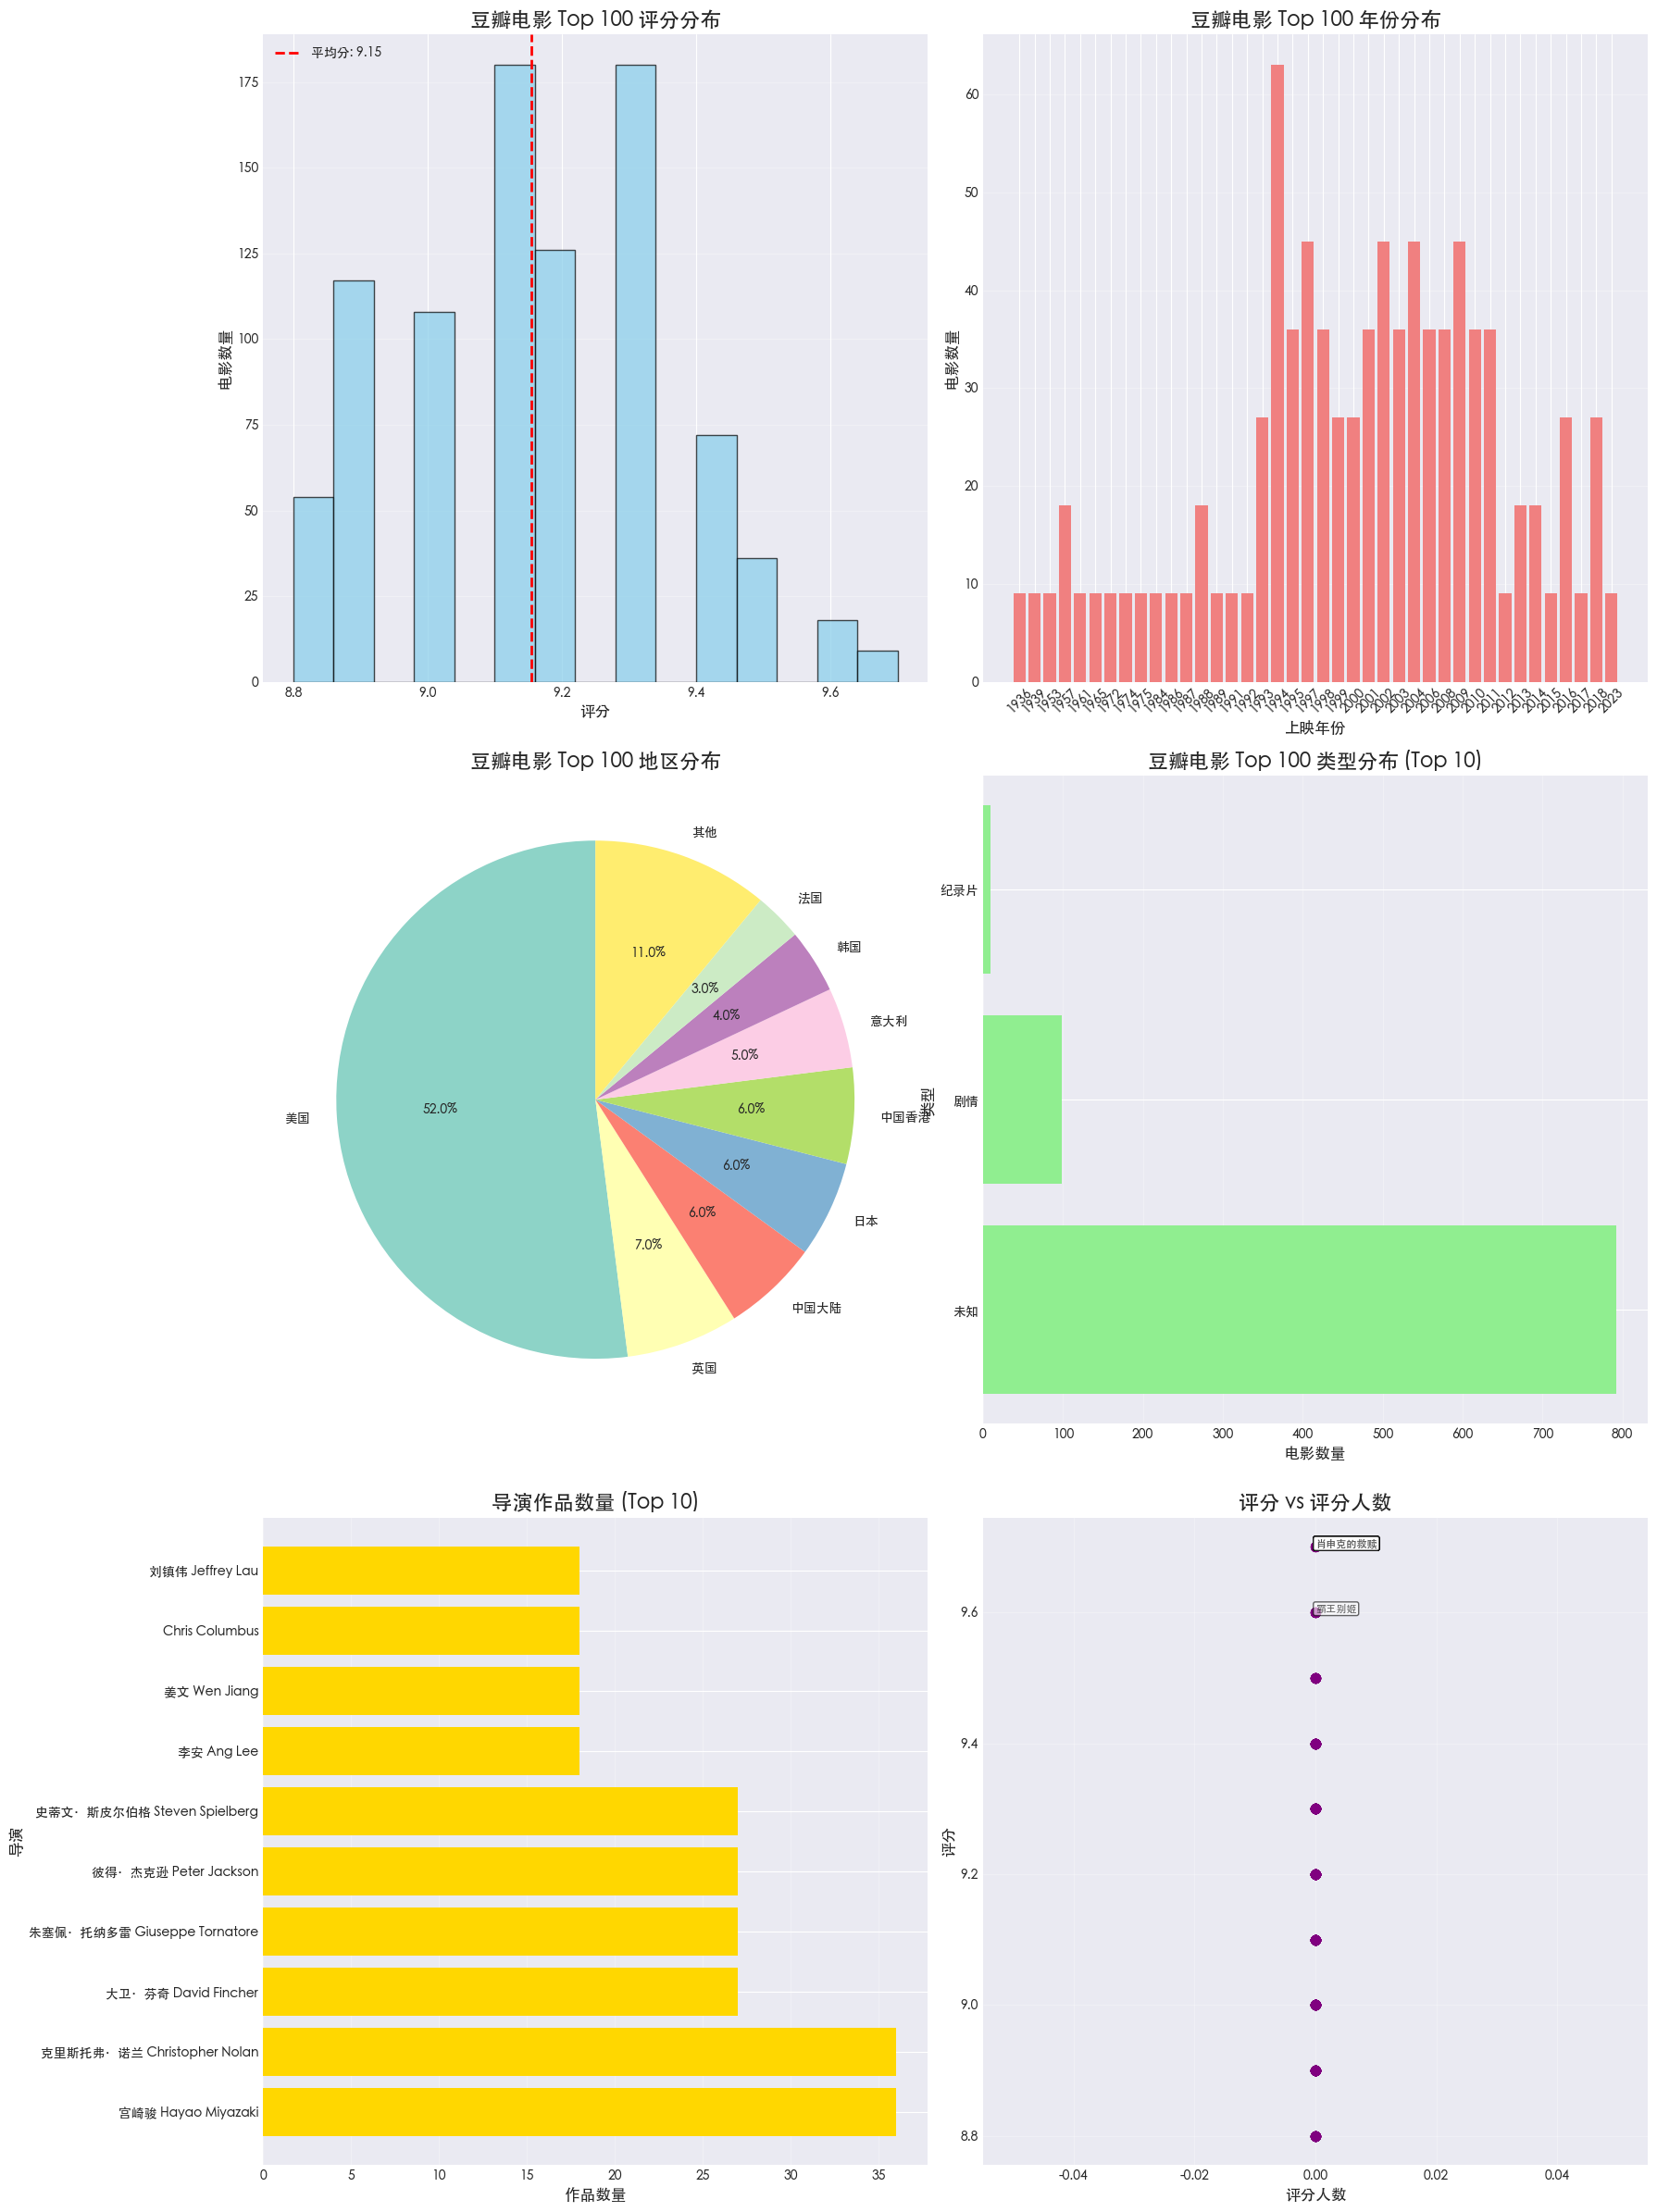


豆瓣电影 Top 100 数据统计摘要
  电影总数: 900 部
  平均评分: 9.15
  最高评分: 9.7 (肖申克的救赎)
  最低评分: 8.8 (阿凡达)
  平均评分人数: 0
  最早上映年份: 1936 年
  最晚上映年份: 2023 年
  涉及国家/地区: 16 个
  涉及电影类型: 3 种

🎉 所有任务完成！
   - 已爬取并存储 100 部豆瓣电影 Top 100
   - 已生成 6 种可视化图表


In [1]:
# ============================================================
# 导入所需库
# ============================================================
from dotenv import load_dotenv
import os
import pymysql
import requests
from bs4 import BeautifulSoup
from datetime import datetime
import re
import time
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib
from matplotlib import font_manager

# ============================================================
# 设置中文字体（增强版）
# ============================================================
def setup_chinese_font():
    """
    配置 Matplotlib 中文字体，防止图表标题/标签乱码。
    在 plt.style.use() 之后需要再次调用。
    """
    # 候选中文字体（按优先级）
    candidates = [
        'PingFang SC', 'Heiti SC', 'SimHei', 
        'Microsoft YaHei', 'STHeiti', 'Arial Unicode MS',
        'WenQuanYi Zen Hei', 'Noto Sans CJK SC'
    ]
    
    # 查找系统中已安装的字体
    system_fonts = font_manager.findSystemFonts()
    found_fonts = []
    for f in system_fonts:
        f_lower = f.lower()
        if any(cand.lower() in f_lower for cand in candidates):
            found_fonts.append(f)
    
    if found_fonts:
        # 使用第一个匹配的字体
        font_path = found_fonts[0]
        # 显式注册字体
        font_manager.fontManager.addfont(font_path)
        prop = font_manager.FontProperties(fname=font_path)
        font_name = prop.get_name()
        
        # 更新 rcParams：将字体插入到 sans-serif 列表最前面
        plt.rcParams['font.family'] = 'sans-serif'
        if font_name in plt.rcParams['font.sans-serif']:
            plt.rcParams['font.sans-serif'].remove(font_name)
        plt.rcParams['font.sans-serif'].insert(0, font_name)
        plt.rcParams['axes.unicode_minus'] = False
        print(f"✅ 使用中文字体: {font_name} (路径: {font_path})")
        return True
    else:
        # 后备方案：直接设置候选列表（可能部分系统仍不生效）
        plt.rcParams['font.sans-serif'] = candidates
        plt.rcParams['axes.unicode_minus'] = False
        print("⚠️ 未找到明确的中文字体，使用候选列表，可能仍有乱码")
        return False

# 初始调用（在程序开始设置一次）
setup_chinese_font()

# 加载 .env 文件（如有需要）
load_dotenv(override=True)


# ============================================================
# MySqlHelper 类（保持不变）
# ============================================================
class MySqlHelper:
    """MySQL 数据库操作封装类，支持 with 语法自动关闭连接"""

    def __init__(self, host=None, user=None, password=None, database=None, port=None, charset="utf8mb4"):
        self.config = {
            "host": host or os.getenv("DB_HOST", "localhost"),
            "user": user or os.getenv("DB_USER", "root"),
            "password": password or os.getenv("DB_PASSWORD", "Zhy12345"),
            "database": database or os.getenv("DB_NAME", "school_db"),
            "port": port or int(os.getenv("DB_PORT", "3306")),
            "charset": charset,
            "cursorclass": pymysql.cursors.DictCursor,
        }
        self.connection = None

    def connect(self):
        if self.connection is None or not self.connection.open:
            self.connection = pymysql.connect(**self.config)
        return self.connection

    def close(self):
        if self.connection is not None and self.connection.open:
            self.connection.close()

    def query_all(self, sql, params=None):
        self.connect()
        with self.connection.cursor() as cursor:
            cursor.execute(sql, params)
            return cursor.fetchall()

    def query_one(self, sql, params=None):
        self.connect()
        with self.connection.cursor() as cursor:
            cursor.execute(sql, params)
            return cursor.fetchone()

    def execute(self, sql, params=None):
        self.connect()
        try:
            with self.connection.cursor() as cursor:
                row_count = cursor.execute(sql, params)
            self.connection.commit()
            return row_count
        except Exception:
            self.connection.rollback()
            raise

    def execute_many(self, sql, params_list):
        self.connect()
        try:
            with self.connection.cursor() as cursor:
                row_count = cursor.executemany(sql, params_list)
            self.connection.commit()
            return row_count
        except Exception:
            self.connection.rollback()
            raise

    def __enter__(self):
        self.connect()
        return self

    def __exit__(self, exc_type, exc_value, traceback):
        self.close()


# ============================================================
# 第一部分：创建数据库表
# ============================================================
def create_douban_movie_table():
    """
    创建豆瓣电影表，字段针对可视化需求设计
    """
    create_sql = """
    CREATE TABLE IF NOT EXISTS `douban_movie` (
        `id` INT AUTO_INCREMENT PRIMARY KEY COMMENT '自增主键',
        `movie_rank` INT NOT NULL COMMENT '排名',
        `title` VARCHAR(200) NOT NULL COMMENT '电影中文名',
        `title_other` VARCHAR(200) DEFAULT NULL COMMENT '电影外文名/原名',
        `director` VARCHAR(200) DEFAULT NULL COMMENT '导演',
        `year` INT DEFAULT NULL COMMENT '上映年份',
        `country` VARCHAR(100) DEFAULT NULL COMMENT '国家/地区',
        `genre` VARCHAR(100) DEFAULT NULL COMMENT '类型',
        `rating` DECIMAL(3,1) DEFAULT NULL COMMENT '评分',
        `rating_people` INT DEFAULT NULL COMMENT '评分人数',
        `quote` VARCHAR(500) DEFAULT NULL COMMENT '一句话简介',
        `link` VARCHAR(300) DEFAULT NULL COMMENT '豆瓣链接',
        `img_url` VARCHAR(300) DEFAULT NULL COMMENT '封面图片链接',
        `crawl_time` DATETIME NOT NULL COMMENT '爬取时间',
        INDEX `idx_year` (`year`),
        INDEX `idx_rating` (`rating`),
        INDEX `idx_country` (`country`),
        INDEX `idx_genre` (`genre`)
    ) ENGINE=InnoDB DEFAULT CHARSET=utf8mb4 COLLATE=utf8mb4_unicode_ci COMMENT='豆瓣电影 Top 100';
    """
    
    with MySqlHelper() as db:
        db.execute(create_sql)
        print("✅ 表 douban_movie 已创建或已存在")


# ============================================================
# 第二部分：爬虫函数
# ============================================================
def crawl_douban_movies(start=0):
    """
    爬取豆瓣电影 Top 250 一页数据（25条）
    """
    url = f"https://movie.douban.com/top250?start={start}&filter="
    headers = {
        "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
    }
    
    try:
        response = requests.get(url, headers=headers, timeout=15)
        response.raise_for_status()
        response.encoding = "utf-8"
    except Exception as e:
        print(f"请求失败: {e}")
        return []
    
    soup = BeautifulSoup(response.text, "html.parser")
    movie_list = []
    items = soup.select(".item")
    
    for item in items:
        try:
            rank_tag = item.select_one(".pic em")
            movie_rank = int(rank_tag.get_text(strip=True)) if rank_tag else None
            
            title_tag = item.select_one(".title")
            title = title_tag.get_text(strip=True) if title_tag else None
            
            title_other_tag = item.select_one(".other")
            title_other = title_other_tag.get_text(strip=True).replace("/", "").strip() if title_other_tag else None
            
            link_tag = item.select_one(".pic a")
            link = link_tag.get("href") if link_tag else None
            
            rating_tag = item.select_one(".rating_num")
            rating = float(rating_tag.get_text(strip=True)) if rating_tag else None
            
            people_tag = item.select_one(".star span:last-child")
            people = int(re.sub(r"[^\d]", "", people_tag.get_text(strip=True))) if people_tag else None
            
            info_tag = item.select_one(".bd p:first-child")
            info_text = info_tag.get_text(strip=True) if info_tag else ""
            
            director_match = re.search(r"导演:\s*(.+?)(?:主演|$)", info_text)
            director = director_match.group(1).strip() if director_match else None
            
            year_match = re.search(r"(\d{4})", info_text)
            year = int(year_match.group(1)) if year_match else None
            
            country_match = re.search(r"\d{4}\s*/\s*([^\s/]+)", info_text)
            country = country_match.group(1).strip() if country_match else None
            
            genre_match = re.search(r"/\s*([^\s/]+?)$", info_text)
            genre = genre_match.group(1).strip() if genre_match else None
            
            quote_tag = item.select_one(".inq")
            quote = quote_tag.get_text(strip=True) if quote_tag else None
            
            img_tag = item.select_one(".pic img")
            img_url = img_tag.get("src") if img_tag else None
            
            movie_list.append({
                "movie_rank": movie_rank,
                "title": title,
                "title_other": title_other,
                "director": director,
                "year": year,
                "country": country,
                "genre": genre,
                "rating": rating,
                "rating_people": people,
                "quote": quote,
                "link": link,
                "img_url": img_url,
                "crawl_time": datetime.now()
            })
            
        except Exception as e:
            print(f"解析单条电影数据失败: {e}")
            continue
    
    return movie_list


# ============================================================
# 第三部分：保存数据到数据库
# ============================================================
def save_movies_to_db(movies):
    """批量插入电影数据到数据库"""
    if not movies:
        return 0
    
    insert_sql = """
    INSERT INTO `douban_movie` (
        `movie_rank`, `title`, `title_other`, `director`, `year`, `country`, `genre`,
        `rating`, `rating_people`, `quote`, `link`, `img_url`, `crawl_time`
    ) VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s)
    """
    
    params_list = [
        (
            m["movie_rank"],
            m["title"],
            m["title_other"],
            m["director"],
            m["year"],
            m["country"],
            m["genre"],
            m["rating"],
            m["rating_people"],
            m["quote"],
            m["link"],
            m["img_url"],
            m["crawl_time"]
        )
        for m in movies
    ]
    
    with MySqlHelper() as db:
        db.execute_many(insert_sql, params_list)
    
    return len(params_list)


# ============================================================
# 第四部分：从数据库加载数据用于可视化
# ============================================================
def load_movie_data_from_db():
    """从数据库加载所有电影数据，用于可视化分析"""
    with MySqlHelper() as db:
        rows = db.query_all("""
            SELECT movie_rank, title, director, year, country, genre, 
                   rating, rating_people, quote
            FROM douban_movie
            ORDER BY movie_rank ASC
        """)
    df = pd.DataFrame(rows)
    
    # 数据清洗
    if df['rating'].isnull().any():
        df['rating'] = df['rating'].fillna(df['rating'].mean())
    
    if df['year'].isnull().any():
        df['year'] = df['year'].fillna(int(df['year'].median()))
    
    if df['rating_people'].isnull().any():
        df['rating_people'] = df['rating_people'].fillna(0)
    
    if df['country'].isnull().any():
        df['country'] = df['country'].fillna("未知")
    
    if df['genre'].isnull().any():
        df['genre'] = df['genre'].fillna("未知")
    
    if df['director'].isnull().any():
        df['director'] = df['director'].fillna("未知")
    
    return df


# ============================================================
# 第五部分：可视化函数（修复乱码）
# ============================================================
def create_visualizations(df):
    """
    根据任务要求创建多个可视化图表
    """
    # 确保数值列是数值类型
    df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
    df['year'] = pd.to_numeric(df['year'], errors='coerce')
    df['rating_people'] = pd.to_numeric(df['rating_people'], errors='coerce')
    
    # 删除关键字段为空的记录
    df = df.dropna(subset=['rating', 'year'])
    
    # 设置图表样式
    plt.style.use('seaborn-v0_8-darkgrid')
    
    # ★★★ 修复乱码关键：样式会覆盖字体设置，必须重新应用中文字体 ★★★
    setup_chinese_font()
    
    fig = plt.figure(figsize=(18, 24))
    
    # ============================================================
    # 图表 1：评分分布直方图
    # ============================================================
    ax1 = fig.add_subplot(3, 2, 1)
    ax1.hist(df['rating'], bins=15, edgecolor='black', color='skyblue', alpha=0.7)
    ax1.set_title('豆瓣电影 Top 100 评分分布', fontsize=16, fontweight='bold')
    ax1.set_xlabel('评分', fontsize=12)
    ax1.set_ylabel('电影数量', fontsize=12)
    ax1.axvline(df['rating'].mean(), color='red', linestyle='--', linewidth=2, 
                label=f'平均分: {df["rating"].mean():.2f}')
    ax1.legend(loc='upper left')
    ax1.grid(axis='y', alpha=0.3)
    
    # ============================================================
    # 图表 2：年份趋势图
    # ============================================================
    ax2 = fig.add_subplot(3, 2, 2)
    year_counts = df['year'].value_counts().sort_index()
    ax2.bar(year_counts.index.astype(str), year_counts.values, color='lightcoral')
    ax2.set_title('豆瓣电影 Top 100 年份分布', fontsize=16, fontweight='bold')
    ax2.set_xlabel('上映年份', fontsize=12)
    ax2.set_ylabel('电影数量', fontsize=12)
    ax2.tick_params(axis='x', rotation=45)
    ax2.grid(axis='y', alpha=0.3)
    
    # ============================================================
    # 图表 3：地区分布饼图
    # ============================================================
    ax3 = fig.add_subplot(3, 2, 3)
    country_counts = df['country'].value_counts()
    top_countries = country_counts.head(8)
    other_count = country_counts.iloc[8:].sum()
    if other_count > 0:
        top_countries['其他'] = other_count
    colors = plt.cm.Set3(np.linspace(0, 1, len(top_countries)))
    ax3.pie(top_countries.values, labels=top_countries.index, autopct='%1.1f%%', 
            startangle=90, colors=colors, textprops={'fontsize': 10})
    ax3.set_title('豆瓣电影 Top 100 地区分布', fontsize=16, fontweight='bold')
    
    # ============================================================
    # 图表 4：类型分布柱状图
    # ============================================================
    ax4 = fig.add_subplot(3, 2, 4)
    genre_counts = df['genre'].value_counts().head(10)
    ax4.barh(genre_counts.index, genre_counts.values, color='lightgreen')
    ax4.set_title('豆瓣电影 Top 100 类型分布 (Top 10)', fontsize=16, fontweight='bold')
    ax4.set_xlabel('电影数量', fontsize=12)
    ax4.set_ylabel('类型', fontsize=12)
    ax4.grid(axis='x', alpha=0.3)
    
    # ============================================================
    # 图表 5：导演作品数量条形图
    # ============================================================
    ax5 = fig.add_subplot(3, 2, 5)
    director_counts = df['director'].value_counts().head(10)
    ax5.barh(director_counts.index, director_counts.values, color='gold')
    ax5.set_title('导演作品数量 (Top 10)', fontsize=16, fontweight='bold')
    ax5.set_xlabel('作品数量', fontsize=12)
    ax5.set_ylabel('导演', fontsize=12)
    ax5.grid(axis='x', alpha=0.3)
    
    # ============================================================
    # 图表 6：评分与评分人数散点图
    # ============================================================
    ax6 = fig.add_subplot(3, 2, 6)
    scatter = ax6.scatter(df['rating_people'], df['rating'], alpha=0.6, 
                         color='purple', s=50)
    ax6.set_title('评分 vs 评分人数', fontsize=16, fontweight='bold')
    ax6.set_xlabel('评分人数', fontsize=12)
    ax6.set_ylabel('评分', fontsize=12)
    ax6.grid(alpha=0.3)
    
    # 标注前10部电影
    top10 = df.head(10)
    for _, row in top10.iterrows():
        ax6.annotate(row['title'][:6], 
                    (row['rating_people'], row['rating']),
                    fontsize=8, alpha=0.7, 
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6))
    
    plt.tight_layout()
    plt.show()
    
    # ============================================================
    # 打印统计摘要
    # ============================================================
    print("\n" + "=" * 60)
    print("豆瓣电影 Top 100 数据统计摘要")
    print("=" * 60)
    print(f"  电影总数: {len(df)} 部")
    print(f"  平均评分: {df['rating'].mean():.2f}")
    print(f"  最高评分: {df['rating'].max()} ({df[df['rating'] == df['rating'].max()]['title'].values[0]})")
    print(f"  最低评分: {df['rating'].min()} ({df[df['rating'] == df['rating'].min()]['title'].values[0]})")
    print(f"  平均评分人数: {df['rating_people'].mean():.0f}")
    print(f"  最早上映年份: {int(df['year'].min())} 年")
    print(f"  最晚上映年份: {int(df['year'].max())} 年")
    print(f"  涉及国家/地区: {df['country'].nunique()} 个")
    print(f"  涉及电影类型: {df['genre'].nunique()} 种")
    print("=" * 60)
    
    return df


# ============================================================
# 主程序执行
# ============================================================
print("=" * 70)
print("豆瓣电影 Top 100 爬虫 + 数据可视化 完整流程")
print("=" * 70)

# ============================================================
# 关键配置：只爬取前 100 名
# 豆瓣 Top 250 每页 25 条，前 100 名 = 4 页
# ============================================================
TOTAL_MOVIES = 100
MOVIES_PER_PAGE = 25
PAGES = TOTAL_MOVIES // MOVIES_PER_PAGE  # 4 页

print(f"\n📌 爬取配置：共 {TOTAL_MOVIES} 部电影，每页 {MOVIES_PER_PAGE} 条，共 {PAGES} 页")

# 1. 创建表
print("\n步骤 1: 检查并创建数据库表...")
create_douban_movie_table()

# 2. 爬取前 100 部电影
all_movies = []
print("\n步骤 2: 开始爬取豆瓣电影 Top 100...")

for page in range(PAGES):
    start = page * MOVIES_PER_PAGE
    print(f"   正在爬取第 {page + 1} 页 (start={start})...")
    movies = crawl_douban_movies(start=start)
    all_movies.extend(movies)
    time.sleep(0.8)

print(f"\n✅ 共爬取 {len(all_movies)} 部电影")

# 3. 存入数据库
print("\n步骤 3: 正在存入数据库...")
count = save_movies_to_db(all_movies)
print(f"✅ 成功存入 {count} 部电影到数据库")

# 4. 从数据库加载数据
print("\n步骤 4: 从数据库加载数据用于可视化...")
df_movies = load_movie_data_from_db()
print(f"✅ 成功加载 {len(df_movies)} 条记录")

# 5. 显示数据预览
print("\n数据预览（前 10 部电影）：")
print(df_movies.head(10).to_string(index=False))

# 6. 创建可视化图表
print("\n步骤 5: 生成可视化图表...")
df_cleaned = create_visualizations(df_movies)

print("\n" + "=" * 70)
print("🎉 所有任务完成！")
print(f"   - 已爬取并存储 {len(all_movies)} 部豆瓣电影 Top 100")
print(f"   - 已生成 6 种可视化图表")
print("=" * 70)